# STAT 207 Project 03 - INSERT TITLE HERE

YOUR NAMES

<hr>

## Contribution Report

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

If you said **my submission is under netID** above, we will not grade any of your project submission.

If you said **grade this submission** above, who worked with you on this project?  Write both their **names** and **netIDs**.  

You should list the contribution of each team member to the report.

*For example:*

*John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*

OR

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

Group Work Reflection

Reflecting on your experience working as a group, how do you think the project went?  What were the most effective things your group did to work together?  What were the least effective things your group did to work together?  What have you learned about group work since the last project?  What might you change about your group's process or dynamics if you were to complete another project together?  Did you face any substantial challenges in working together?  If so, please explain any challenges that you had.

*Note*: this can be completed individually or as a group, and each person can submit their own reflection to their own repository/submission or completely within the group submission.  If you would like your TA to read your individual reflection and yours is not the submission to be graded, be sure to email your TA.

The project went well working together. We combined our knowledge on each part of the project, working equally throughout it. We did not face any major challenges in the project while working together. We have completed every project together and each has went smoothly. 

## 1. Introduction

- Throughout our report, you will read all about NFL data and how it relates to players inside of specific games. The data set we are using comes from the 2025 NFL season. Observations are certain plays from each game and include information including yards gained, score differential, time remaining, touchdowns, and many more interesting facts. 
- For our first research question, we will ask, "What factors influence the yards gained in a certain play?". For our second, we will ask, "What factors influences a player stepping out of bounds in a play?". Our response variables for these questions will be yards_gained and out_of_bounds, respectively. 
- These questions could be very important to a head coach or staff of an NFL team. They might want to reduce the number of times a player goes out of bounds to stop the clock less. Also, if a player wants to gain more yards in order to be paid more, they could look at what factors are important to do so. ## 1. Introduction

In [2]:
#Imports here
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [3]:
# reading in data (clean data without missing values and with relevant columns is read from play_by_play.csv)
df = pd.read_csv("play_by_play_2025.csv")
df 

,game_id,quarter_seconds_remaining,yards_gained,air_yards,score_differential,incomplete_pass,interception,penalty,touchdown,complete_pass,out_of_bounds,pass_length
0,2025_01_ARI_NO,858.0,11.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,1,short
1,2025_01_ARI_NO,655.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0,short
2,2025_01_ARI_NO,651.0,0.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0,short
3,2025_01_ARI_NO,634.0,5.0,-3.0,0.0,0.0,0.0,0.0,0.0,1.0,0,short
4,2025_01_ARI_NO,398.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0,short
...,...,...,...,...,...,...,...,...,...,...,...,...
18283,2025_22_SEA_NE,90.0,5.0,5.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18284,2025_22_SEA_NE,72.0,11.0,11.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18285,2025_22_SEA_NE,39.0,9.0,7.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18286,2025_22_SEA_NE,20.0,0.0,49.0,-16.0,1.0,0.0,0.0,0.0,0.0,0,deep


In [4]:
# some games in 2025 are better represented than others 
# but all have the same order of magnitude of plays represented so we are not droping and more data
df["game_id"].value_counts()

game_id
2025_16_PIT_DET    95
2025_13_DEN_WAS    95
2025_19_GB_CHI     94
2025_05_SF_LA      94
2025_02_NYG_DAL    93
                   ..
2025_15_LV_PHI     43
2025_02_ATL_MIN    42
2025_18_GB_MIN     42
2025_12_MIN_GB     41
2025_16_MIN_NYG    36
Name: count, Length: 285, dtype: int64

Text(0, 0.5, '# of occurances in 2025')

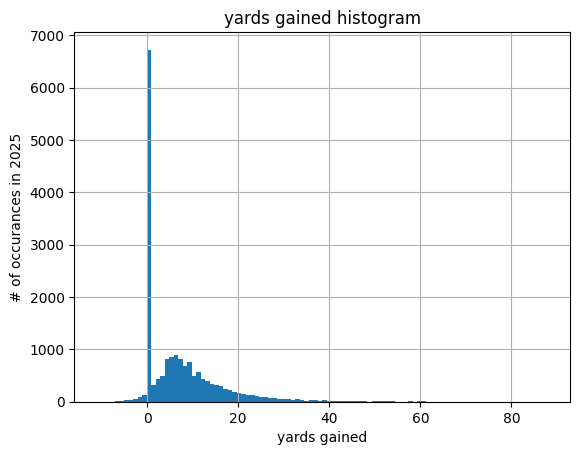

In [5]:
# The mode of yards gained is 0 by a long shot
df["yards_gained"].hist(bins = 100)
plt.title("yards gained histogram")
plt.xlabel("yards gained")
plt.ylabel("# of occurances in 2025")

Text(0, 0.5, '# of occurances in 2025')

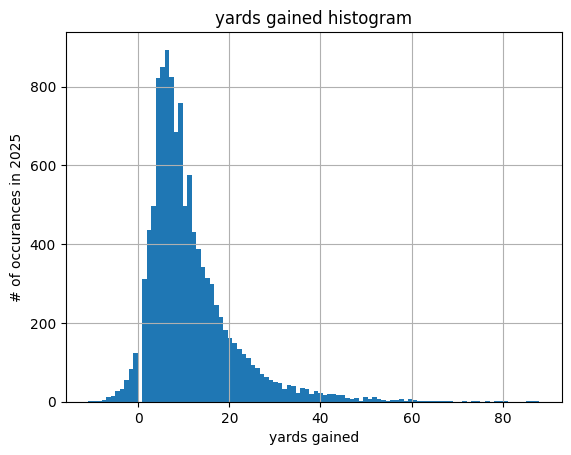

In [6]:
# excluding 0, the yards gained distribution is normal (telling visually)
df[df["yards_gained"]!=0]["yards_gained"].hist(bins = 100)
plt.title("yards gained histogram")
plt.xlabel("yards gained")
plt.ylabel("# of occurances in 2025")

In [7]:
# the men of the above pictured distribution is 11.11 yards, its standard deviation is 9.65 yards
# the min of -11 and the max of 88 yards both mke sense so there is no cause to remove data
df[df["yards_gained"]!=0]["yards_gained"].describe()

count    11566.000000
mean        11.117413
std          9.654277
min        -11.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         88.000000
Name: yards_gained, dtype: float64

## 2. Linear Regression Analytical Tasks

## 3. Logistic Regression Analytical Tasks

- Our research question for this section is, "What factors influence a player stepping out of bounds in a play?" Specifically, we want to focus on how the time remaining in a quater, the current score differential, and the depth of a pass affect the log odds of a play ending out of bounds. 

In [ ]:
# Looking at the data for completed passes in the data set
df_complete_pass = df[df['complete_pass'] == 1].copy()
df_complete_pass[['quarter_seconds_remaining', 'air_yards', 'score_differential']].describe()

,quarter_seconds_remaining,air_yards,score_differential
count,11749.000000,11749.000000,11749.000000
mean,424.971827,5.786280,-2.759043
std,273.418456,8.405569,10.033036
min,1.000000,-11.000000,-45.000000
25%,175.000000,1.000000,-7.000000
50%,412.000000,4.000000,-3.000000
75%,667.000000,9.000000,3.000000
max,900.000000,53.000000,39.000000


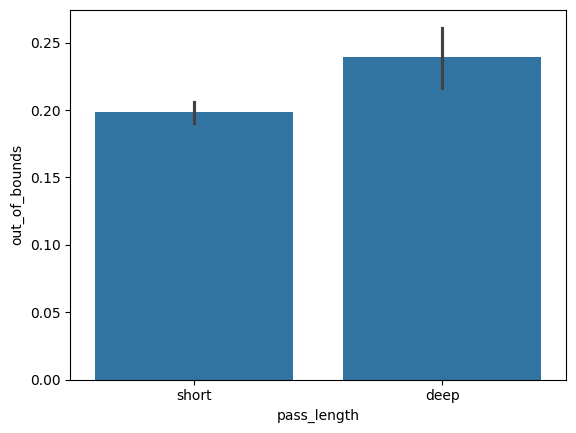

In [ ]:
# Deeper the pass, more likely it ends in an out of bounds
import seaborn as sns
sns.barplot(x='pass_length', y='out_of_bounds', data=df_complete_pass)
plt.show()

In [ ]:
# Splits our original data into training and test sections for our upcoming model
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=40)

In [15]:
# Logistic model for out_of_bounds variable
model = smf.logit('out_of_bounds~score_differential+quarter_seconds_remaining+air_yards+pass_length', data=df_train).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.395158
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          out_of_bounds   No. Observations:                14630
Model:                          Logit   Df Residuals:                    14625
Method:                           MLE   Df Model:                            4
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                0.004432
Time:                        10:55:10   Log-Likelihood:                -5781.2
converged:                       True   LL-Null:                       -5806.9
Covariance Type:            nonrobust   LLR p-value:                 1.781e-10
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.5611      0.120    -12.999      0.000      -1.

### Model Interpretations
- quarter_seconds_remaining - Lower values in seconds remaining result in a higher probability of the play ending out of bounds. This result is shown by the negative coefficient. This makes sense because players would want to stop the clock to save time at the end of a quarter.
- pass_length - Deep passes are more likely to go out of bounds. We can see this based on the negative coefficient for when pass length is short. This makes sense because the deeper you throw it, the more likely you are to step out when running away from a defender.
- air_yards - Lower values are associated with a higher log odds in out of bounds. Lower air yardage has a higher probability of being near the sideline or back of end zone. 
- score_differential - Higher score differential associates with a higher log odds of players going out of bounds. This makes sense because teams would need to save time on the clock to try to make the score even. 

I am using the probability threshold of 50% for this model. 

In [17]:
predictions = (model.predict(df_test) > 0.5).astype(int)
matrix = pd.crosstab(df_test['out_of_bounds'], predictions, rownames=['Actual'], colnames=['Predicted'])
print(matrix)

Predicted     0  1
Actual            
0          3159  1
1           498  0


In [20]:
accuracy = (0 + 1873) / 2350
sens = 0 / (0 + 477)
spec = 1873 / (0 + 1873)
print(accuracy)
print(sens)
print(spec)

0.7970212765957447
0.0
1.0


- The accuracy of this is so high even with the sens being so low because most of the plays in our data set stay in bounds. If the model always predicts in bounds, it will often be correct because of the play never going out of bounds. 
- We would want to minimize false negatives with our model. This is because we are finding the factos that influence stepping out of bounds. A model that never predicts an out of bounds play will not be much help in the long run. We could move the current threshold to something lower like 0.2-0.3 to help with our predictions. 
- Based on the current evaluations, I am not satisfied with the performance of our classifier. While almost 80% accuracy looks great, the sens of 0% changes things. A majority of our plays stay in bounds, and this model gains its accuracy by predicting in bounds for every play, which is not a good thing. If we wanted a more accurate prediction, different factors would need to be included in our model. 

##### Psuedo-R^2
- The model shows that we have a Psuedo-R^2 of 0.004432. This value is quite low, but can make sense for football data. It shows that our predictors are significant, but do not fully capture why a play ends in out of bounds. Factors not shown including where the defenser is, route ran, and throw accuracy are not shown.


In [19]:
# AUC calculations
from sklearn.metrics import roc_auc_score
probabilities = model.predict(df_test)
auc = roc_auc_score(df_test['out_of_bounds'], probabilities)
print(auc)

0.5322282802094453


##### AUC
- Our auc score of 0.5322 is not the best. With it being near 0.5, it is almost a 50/50 chance that the model predicts the right thing. This shows it does not have great predictive power. 

### Assumptions of Logistic Regression
- The required form for the response variable is a 0 or 1. You can see this is met in our data set under the out_of_bounds column. 


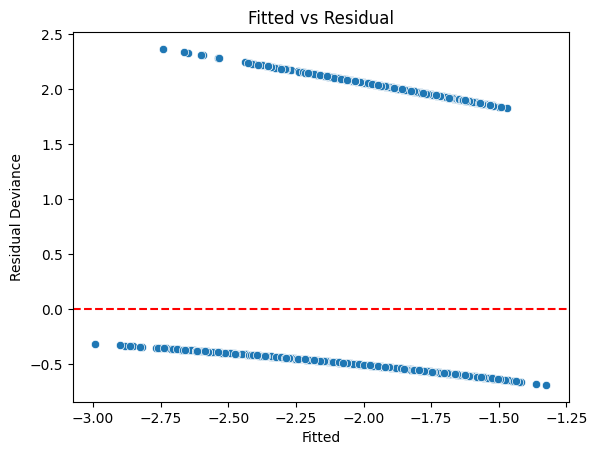

In [21]:
sns.scatterplot(x=model.fittedvalues, y=model.resid_dev)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted")
plt.ylabel("Residual Deviance")
plt.title("Fitted vs Residual")
plt.show()

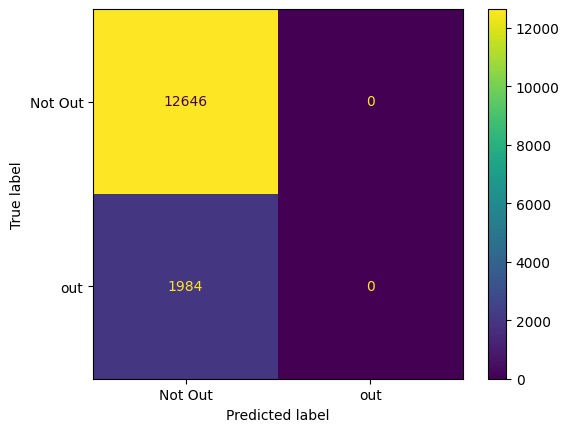

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion = confusion_matrix(df_train['out_of_bounds'], 1 * (model.predict(df_train) > 0.5))
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=['Not Out', 'out'])
display.plot()
plt.show()

## 4. Conclusion

## AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class.  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.